# Testing how markers work with brainflow and the OpenBCI Cyton

https://docs.openbci.com/Software/OpenBCISoftware/GUIDocs/#cyton

In [2]:
import sys
import os
import time
import matplotlib.pyplot as plt
# from scipy.signal import butter, filtfilt, lfilter
from scipy import signal
import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler

In [1]:
import sys
sys.path.append("..") # So that it can find the modules
# Assuming the other modules (brainflow_stream, filtering, segmentation, classification) are available
from modules.brainflow_stream import *
from modules.filtering import *
from modules.segmentation import *
from modules.classification import *
from modules.ssvep_stim import *

from modules.visualization import *

pygame 2.2.0 (SDL 2.26.5, Python 3.10.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
board_id = BoardIds.CYTON_BOARD.value

# board = BrainFlowBoardSetup(board_id = BoardIds.PLAYBACK_FILE_BOARD.value,
#                             file = '../120s_cyton_recording.csv', # ~120s recording where participant looked at each stimulus for 15 seconds before switching clock-wise to the next
#                             master_board = BoardIds.CYTON_BOARD.value )

board = BrainFlowBoardSetup(board_id = board_id)

# board.setup()

In [5]:
print(BoardShim.get_board_descr(board_id))

{'accel_channels': [9, 10, 11], 'analog_channels': [19, 20, 21], 'ecg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eeg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eeg_names': 'Fp1,Fp2,C3,C4,P7,P8,O1,O2', 'emg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eog_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'marker_channel': 23, 'name': 'Cyton', 'num_rows': 24, 'other_channels': [12, 13, 14, 15, 16, 17, 18], 'package_num_channel': 0, 'sampling_rate': 250, 'timestamp_channel': 22}


In [ ]:
board.stop()
board.setup()

[Board 1, COM3] Streaming stopped.
[Board 1, COM3] Session released.


In [112]:
print(BoardShim.get_board_presets(board_id))

[0]


In [102]:
for i in range(5):
    board.insert_marker(i+2)
    time.sleep(1)

[Board 1] Marker 2 inserted successfully.
[Board 1] Marker 3 inserted successfully.
[Board 1] Marker 4 inserted successfully.
[Board 1] Marker 5 inserted successfully.
[Board 1] Marker 6 inserted successfully.


In [103]:
n_samples = 2000
eeg_data = board.get_current_board_data(num_samples = n_samples)

In [104]:
eeg_data.shape

(24, 2000)

In [105]:
print(np.unique(eeg_data[23, :]))

[0.]


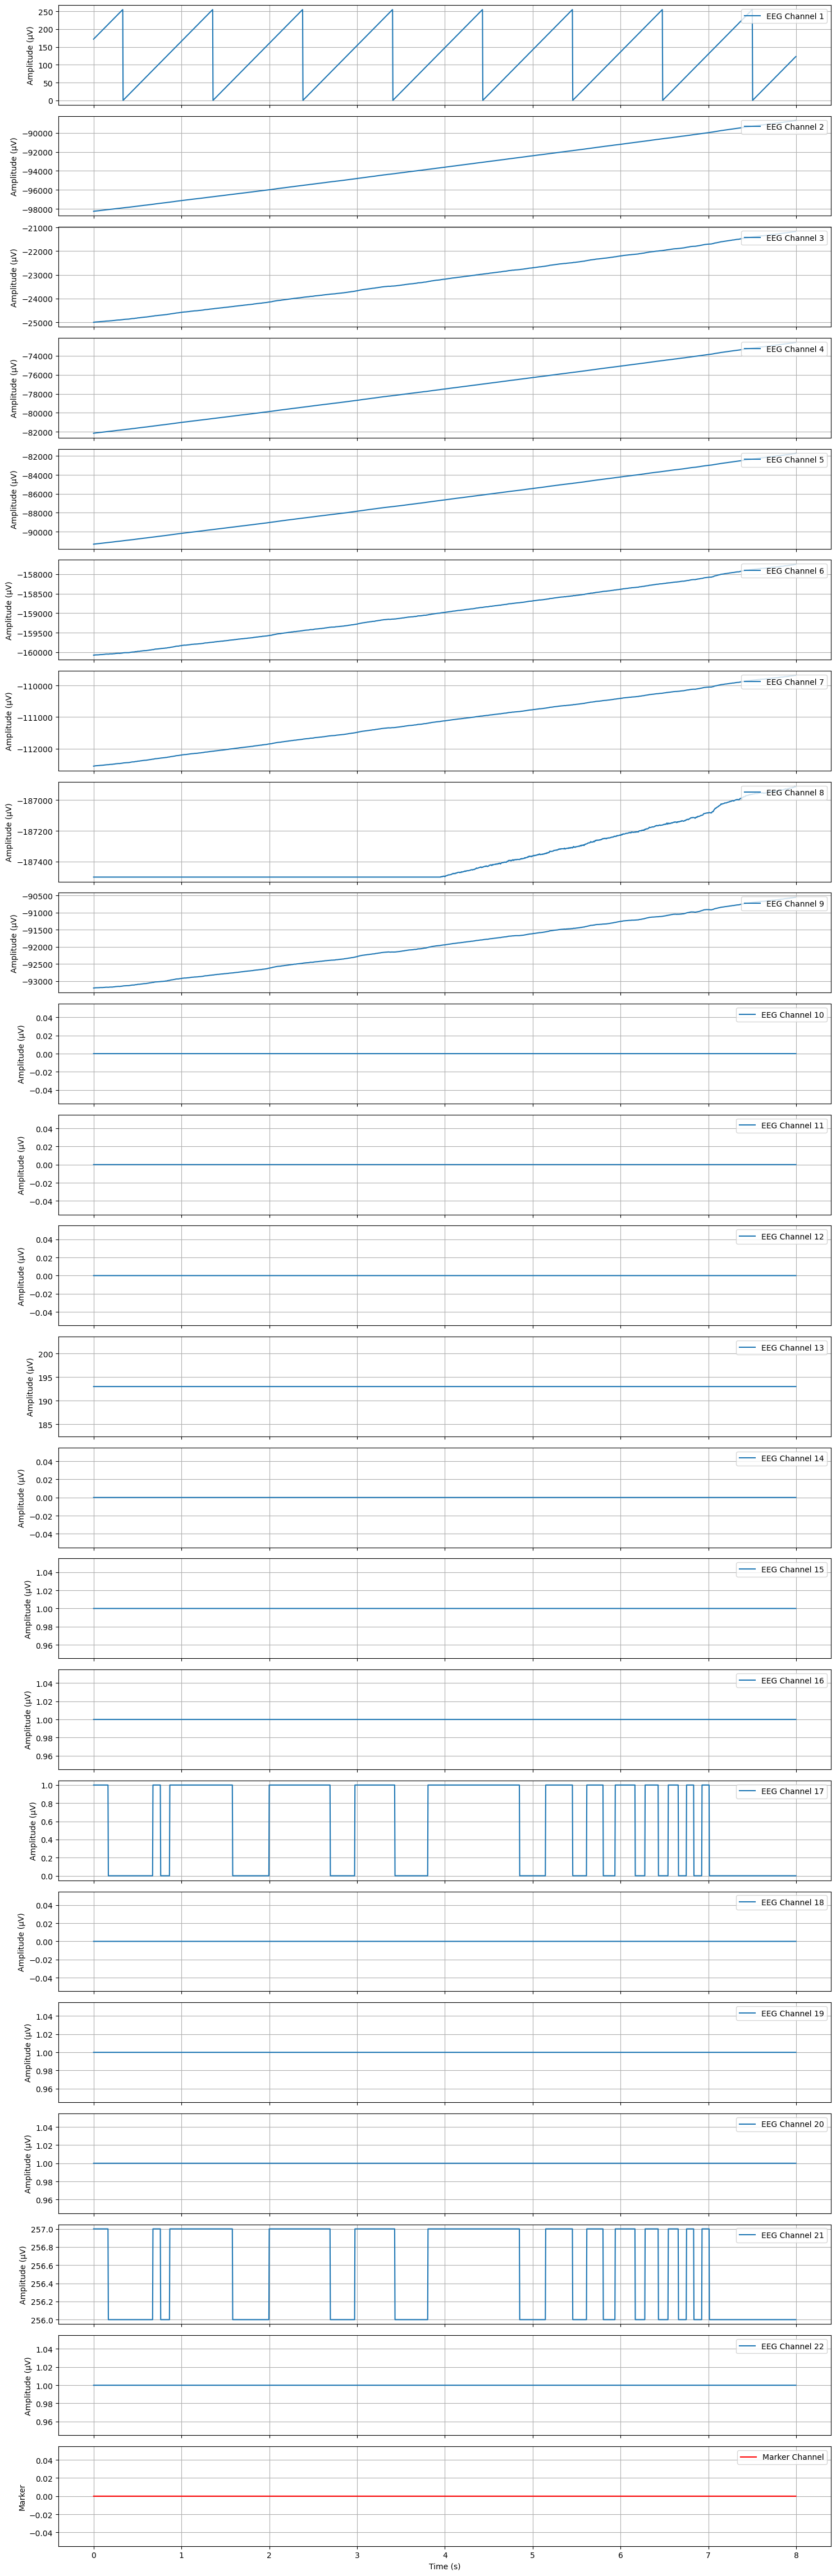

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_all_channels_separately(data, sampling_rate=250):
    """
    Visualize each EEG channel (1-22) on its own axis and scale, with the marker channel (23) at the bottom.

    Parameters:
        data (numpy.ndarray): EEG data array of shape (n_channels, n_samples).
        sampling_rate (int): Sampling rate of the data in Hz.
    """
    eeg_channels = data[:22]  # Channels 1-22 (0-indexed)
    marker_channel = data[23]  # Channel 23 (0-indexed)

    time = np.arange(data.shape[1]) / sampling_rate  # Time axis in seconds

    # Create a figure with subplots for each channel
    n_channels = eeg_channels.shape[0]
    fig, axes = plt.subplots(n_channels + 1, 1, figsize=(15, 2 * (n_channels + 1)), sharex=True)

    for i, (ax, channel) in enumerate(zip(axes[:-1], eeg_channels), start=1):
        ax.plot(time, channel, label=f"EEG Channel {i}")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(loc="upper right")
        ax.grid(True)

    # Plot marker channel in the last subplot
    axes[-1].plot(time, marker_channel, color="red", label="Marker Channel")
    axes[-1].set_xlabel("Time (s)")
    axes[-1].set_ylabel("Marker")
    axes[-1].legend(loc="upper right")
    axes[-1].grid(True)

    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `eeg_data` is a numpy array of shape (n_channels, n_samples)

visualize_all_channels_separately(eeg_data)

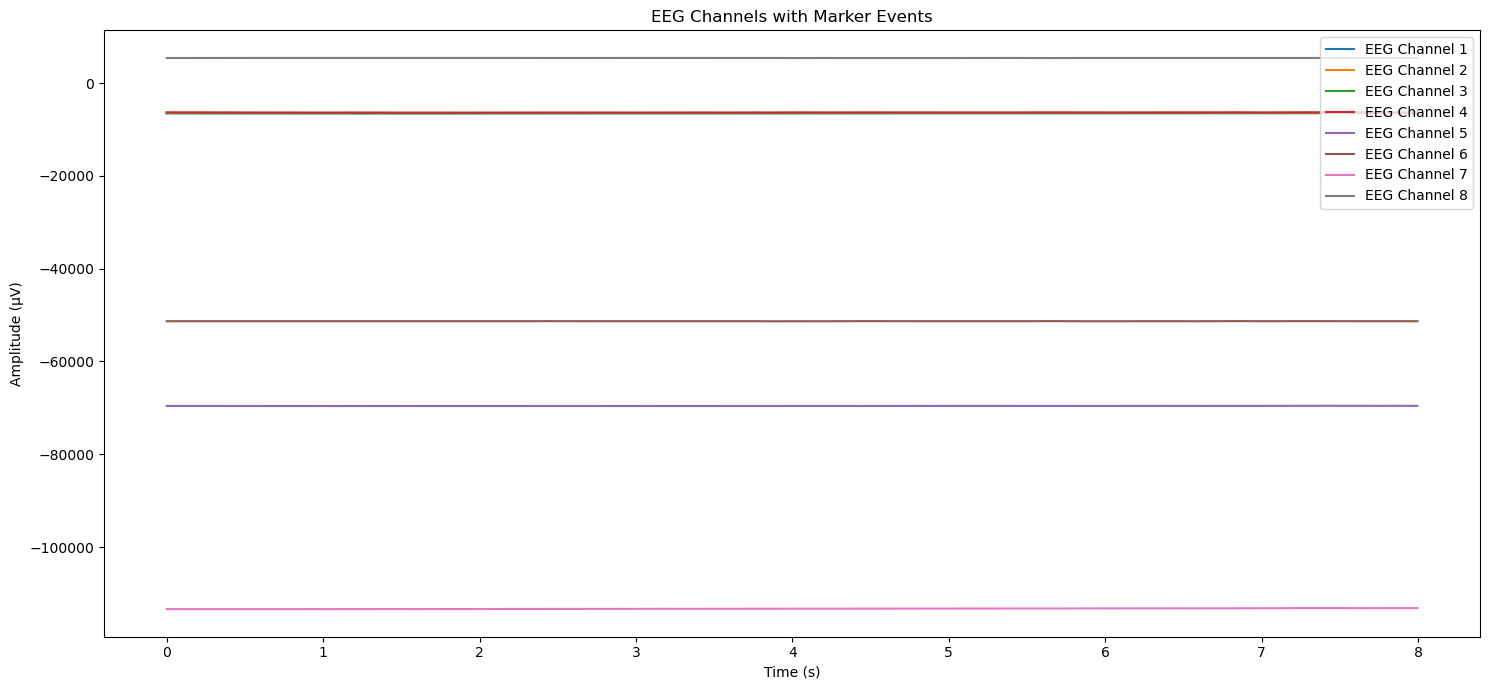

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_eeg_data(data, sampling_rate=250):
    """
    Visualize EEG data and marker channel on a single axis with markers.

    Parameters:
        data (numpy.ndarray): EEG data array of shape (n_channels, n_samples).
        sampling_rate (int): Sampling rate of the data in Hz.
    """
    eeg_channels = data[1:9]  # Channels 1:9 (0-indexed)
    marker_channel = data[23]  # Channel 23 (0-indexed)

    time = np.arange(data.shape[1]) / sampling_rate  # Time axis in seconds

    # Plot EEG channels on the same axis
    plt.figure(figsize=(15, 7))
    for i, channel in enumerate(eeg_channels, start=1):
        plt.plot(time, channel + (i * 50), label=f"EEG Channel {i}")  # Offset each channel for clarity

    # Add markers and vertical lines
    marker_positions = np.where(marker_channel > 0)[0]
    for pos in marker_positions:
        marker_time = pos / sampling_rate
        marker_value = marker_channel[pos]
        plt.axvline(marker_time, color='red', linestyle='--', alpha=0.7)
        plt.text(marker_time, eeg_channels.min() - 100, f"{int(marker_value)}",
                 rotation=90, color='red', verticalalignment='bottom')

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.title("EEG Channels with Marker Events")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

visualize_eeg_data(eeg_data)
